<a href="https://colab.research.google.com/github/Krishnapriyathankamaninair/Casestudy-on-Python-Basics/blob/main/Exit_exam_Customer_Churn_Risk_%26_AI_Retention_Advisor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [176]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import joblib
import os
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [177]:
url = "https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Task 1: Explore the Data as a KPI Story

In [178]:
#Overall churn rate

df["Churn_Binary"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

overall_churn_rate = df["Churn_Binary"].mean() * 100

print(f"Overall Churn Rate: {overall_churn_rate:.2f}%")

#Churn rate by Contract type
contract_churn = (
    df.groupby("Contract")["Churn_Binary"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)


contract_churn_df = contract_churn.reset_index()
contract_churn_df.columns = ["Contract Type", "Churn Rate (%)"]

display(contract_churn_df)


#Churn rate by InternetService type
internet_churn = (
    df.groupby("InternetService")["Churn_Binary"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)


print("Churn Rate by Internet Service:")
internet_churn_df = internet_churn.reset_index()
internet_churn_df.columns = ["Internet Service", "Churn Rate (%)"]

display(internet_churn_df)

Overall Churn Rate: 26.54%


,Contract Type,Churn Rate (%)
0,Month-to-month,42.71
1,One year,11.27
2,Two year,2.83


Churn Rate by Internet Service:


,Internet Service,Churn Rate (%)
0,Fiber optic,41.89
1,DSL,18.96
2,No,7.40


Correlation between Tenure and Churn

In [179]:
tenure_churn_corr = df["tenure"].corr(df["Churn_Binary"])

print(f"Correlation between Tenure and Churn: {tenure_churn_corr:.4f}")




Correlation between Tenure and Churn: -0.3522


In [180]:
print("=" * 60)
print("TELCO CUSTOMER CHURN – KPI ANALYSIS")
print("=" * 60)

print(f"\nOverall Churn Rate: {overall_churn_rate:.2f}%")

print("\nChurn Rate by Contract Type:")
for contract, rate in contract_churn.items():
    print(f"  {contract}: {rate:.2f}%")

print("\nChurn Rate by Internet Service:")
for service, rate in internet_churn.items():
    print(f"  {service}: {rate:.2f}%")

print(f"\nCorrelation between Tenure and Churn: {tenure_churn_corr:.4f}")

print("\nChurn Rate by Tenure Group:")
for tenure_group, rate in tenure_churn.items():
    print(f"  {tenure_group}: {rate:.2f}%")

TELCO CUSTOMER CHURN – KPI ANALYSIS

Overall Churn Rate: 26.54%

Churn Rate by Contract Type:
  Month-to-month: 42.71%
  One year: 11.27%
  Two year: 2.83%

Churn Rate by Internet Service:
  Fiber optic: 41.89%
  DSL: 18.96%
  No: 7.40%

Correlation between Tenure and Churn: -0.3522

Churn Rate by Tenure Group:
  0-12 months: 47.44%
  13-24 months: 28.71%
  25-36 months: 21.63%
  37-48 months: 19.03%
  49-60 months: 14.42%
  61-72 months: 6.61%


Anautical Interepretation:

The overall Churn rate is 26.54% and Month to Month churn rate is the heighest  42.71%.However, this should not be interpreted as proof that changing customers to two-year contracts would automatically reduce churn. Contract choice is may be also related to other customer characteristics. Therefore, contract type and churn are correlated, but the analysis alone cannot establish that contract length causes the difference in churn.

Part 2: Predictive Modelling & Business Segmentation

In [181]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing values after TotalCharges conversion:")
print(df["TotalCharges"].isnull().sum())


before = len(df)

df = df.dropna(subset=["TotalCharges"]).copy()

after = len(df)

print(f"Rows before cleaning: {before}")
print(f"Rows after cleaning:  {after}")
print(f"Rows removed:         {before - after}")

df = df.drop(columns=["customerID"])

print("Shape after dropping customerID:", df.shape)

duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates().copy()
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")



    categorical_columns = df.select_dtypes(
    include=["object"]
).columns



Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Binary']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
Churn_Binary          int64
dtype: object

Mi

In [182]:
X = df.drop(columns=["Churn", "Churn_Binary"])
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Identify numerical and categorical features
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Train-test split

In [183]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining churn distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest churn distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set: (5608, 19)
Test set: (1402, 19)

Training churn distribution:
Churn
0    73.50214
1    26.49786
Name: proportion, dtype: float64

Test churn distribution:
Churn
0    73.537803
1    26.462197
Name: proportion, dtype: float64


In [184]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

Train, Evaluate and Check Trust



Baseline model used:Logistic Regression

Complex model used:Random Forest


In [185]:
#Logistic regression
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

# Train
logistic_model.fit(X_train, y_train)

# Predictions
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [186]:
#Random Forest
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=15,
                min_samples_split=5,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train
random_forest_model.fit(X_train, y_train)

# Predictions
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [187]:
def evaluate_model(name, model, X_test, y_test, X_train, y_train):

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Probabilities
    test_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    precision = precision_score(
        y_test,
        test_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        test_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        test_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        test_prob
    )

    cm = confusion_matrix(
        y_test,
        test_pred
    )

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print(f"Training Accuracy : {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
    print(f"Test Accuracy     : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")
    print(f"F1 Score          : {f1:.4f}")
    print(f"ROC-AUC           : {auc:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            test_pred,
            target_names=["No Churn", "Churn"],
            zero_division=0
        )
    )

    return {
        "Model": name,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": auc
    }

results_lr = evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_test,
    y_test,
    X_train,
    y_train
)

results_rf = evaluate_model(
    " Random Forest",
    random_forest_model,
    X_test,
    y_test,
    X_train,
    y_train
)



Logistic Regression
Training Accuracy : 0.8053 (80.53%)
Test Accuracy     : 0.8081 (80.81%)
Precision         : 0.6700
Recall            : 0.5418
F1 Score          : 0.5991
ROC-AUC           : 0.8472

Confusion Matrix:
[[932  99]
 [170 201]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1031
       Churn       0.67      0.54      0.60       371

    accuracy                           0.81      1402
   macro avg       0.76      0.72      0.74      1402
weighted avg       0.80      0.81      0.80      1402


 Random Forest
Training Accuracy : 0.9187 (91.87%)
Test Accuracy     : 0.7853 (78.53%)
Precision         : 0.5854
Recall            : 0.6469
F1 Score          : 0.6146
ROC-AUC           : 0.8337

Confusion Matrix:
[[861 170]
 [131 240]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.84      0.85      1031
       Churn       0.59      0.65  

In [188]:
results = pd.DataFrame([
    results_lr,
    results_rf
])

display(
    results.style.format({
        "Train Accuracy": "{:.2%}",
        "Test Accuracy": "{:.2%}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,80.53%,80.81%,0.6700,0.5418,0.5991,0.8472
1,Random Forest,91.87%,78.53%,0.5854,0.6469,0.6146,0.8337


In [189]:
best_model_name = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]

print("Best model based on F1-score:")
print(best_model_name)

Best model based on F1-score:
 Random Forest


In [190]:
churn_rate = y.mean()
no_churn_rate = 1 - churn_rate

print(f"Churn rate:     {churn_rate:.2%}")
print(f"No-churn rate:  {no_churn_rate:.2%}")

print(
    f"\nA model that predicted 'No Churn' for EVERY customer "
    f"would achieve approximately {no_churn_rate:.2%} accuracy."
)

Churn rate:     26.49%
No-churn rate:  73.51%

A model that predicted 'No Churn' for EVERY customer would achieve approximately 73.51% accuracy.


In [191]:
y_pred = random_forest_model.predict(X_test)


churn_rate = y_test.mean() * 100


majority_accuracy = (1 - y_test.mean()) * 100


model_accuracy = accuracy_score(y_test, y_pred) * 100


recall = recall_score(y_test, y_pred) * 100




cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

actual_churners = TP + FN
correctly_identified = TP
missed_churners = FN

missed_percentage = (FN / actual_churners) * 100


print(f"Overall churn rate:              {churn_rate:.2f}%")
print(f"Non-churn rate:                  {majority_accuracy:.2f}%")
print(f"Model accuracy:                  {model_accuracy:.2f}%")
print(f"Model recall:                    {recall:.2f}%")

print("\nActual churners in test set:     ", actual_churners)
print("Correctly identified churners:  ", correctly_identified)
print("Missed churners:                 ", missed_churners)
print(f"Percentage of churners missed:   {missed_percentage:.2f}%")

Overall churn rate:              26.46%
Non-churn rate:                  73.54%
Model accuracy:                  78.53%
Model recall:                    64.69%

Actual churners in test set:      371
Correctly identified churners:   240
Missed churners:                  131
Percentage of churners missed:   35.31%


 Analytical Question A:26.54% is the overall  churn rate, churners are clearly the minority class. This means that a model could achieve about 73.46% accuracy simply by predicting “No Churn” for every customer, without identifying a single customer who actually leaves. Therefore, accuracy alone would flatter the model because it is dominated by the majority class

In [192]:
rf_train_accuracy = results_rf["Train Accuracy"]
rf_test_accuracy = results_rf["Test Accuracy"]

accuracy_gap = rf_train_accuracy - rf_test_accuracy

print("Random Forest Training Accuracy:",
      f"{rf_train_accuracy:.2%}")

print("Random Forest Test Accuracy:",
      f"{rf_test_accuracy:.2%}")

print("Accuracy Gap:",
      f"{accuracy_gap:.2%}")

Random Forest Training Accuracy: 91.87%
Random Forest Test Accuracy: 78.53%
Accuracy Gap: 13.34%


 Analytical Question B:The Random Forest model achieved a training accuracy of 91.87%, but its test accuracy was only 78.53%, resulting in a relatively large accuracy gap of 13.34 percentage points. This indicates that the model is likely overfitting the training data.

Task 4: Feature Importance for Strategy

1. Contract → Importance = 0.1624
2. tenure → Importance = 0.1323
3. TotalCharges → Importance = 0.1183


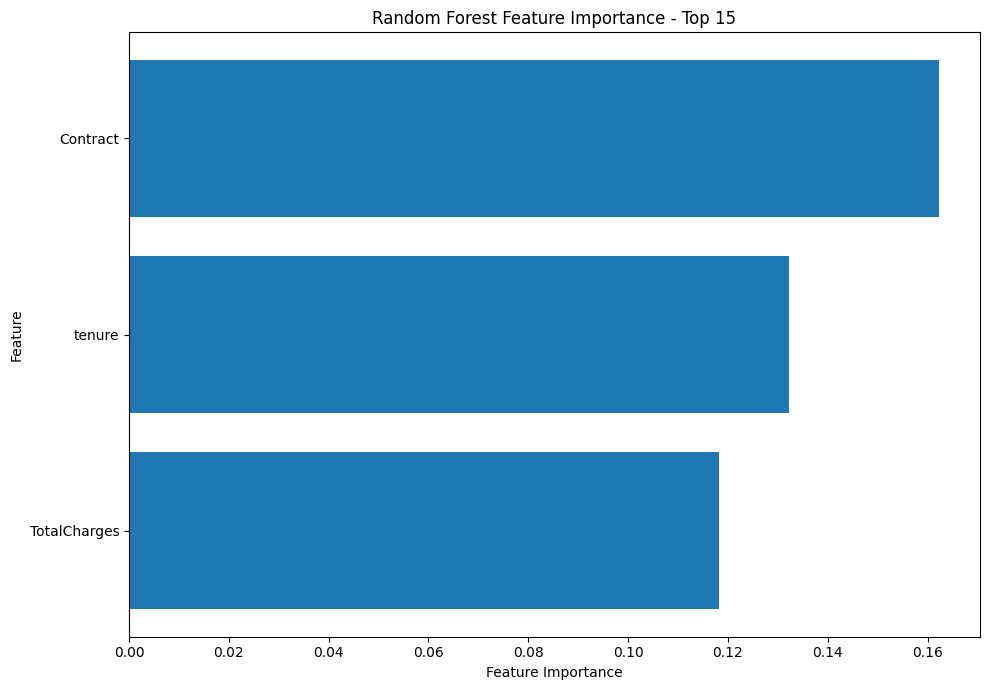

In [193]:
preprocessor_fitted = random_forest_model.named_steps["preprocessor"]
rf_fitted = random_forest_model.named_steps["classifier"]

# Get transformed feature names
feature_names = preprocessor_fitted.get_feature_names_out()

# Get Random Forest importance
importance_values = rf_fitted.feature_importances_

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)



def get_original_feature(encoded_name):

    # Numerical features
    if encoded_name.startswith("num__"):
        return encoded_name.replace("num__", "")

    # Categorical features
    if encoded_name.startswith("cat__"):
        name = encoded_name.replace("cat__", "")

        for col in categorical_features:
            if name.startswith(col + "_"):
                return col

        return name

    return encoded_name


# Map encoded features to original features
feature_importance["Original_Feature"] = (
    feature_importance["Feature"]
    .apply(get_original_feature)
)

# Aggregate importance
aggregated_importance = (
    feature_importance
    .groupby("Original_Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)


top3 = aggregated_importance.head(3)

for i, row in top3.iterrows():
    print(
        f"{i+1}. {row['Original_Feature']} "
        f"→ Importance = {row['Importance']:.4f}"
    )


top_n = 3

top_features = aggregated_importance.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Original_Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance - Top 15")

plt.tight_layout()
plt.show()

Contract → Identify month-to-month customers at high churn risk and offer a discounted one-year/two-year contract upgrade.

tenure → Target customers within their first 12 months with an early-renewal incentive or contract-upgrade offer.

TotalCharges→Identify customers with high cumulative charges and offer a loyalty discount or bundled service upgrade to increase perceived value.

Task 5: Segment Customers for Targeting

In [194]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#Probability of Churn
churn_probability = random_forest_model.predict_proba(X)[:, 1]

# Create segmentation dataframe
segment_df = df[["tenure", "MonthlyCharges"]].copy()

segment_df["ChurnProbability"] = churn_probability


clustering_features = [
    "tenure",
    "MonthlyCharges",
    "ChurnProbability"
]

scaler = StandardScaler()

X_cluster = scaler.fit_transform(
    segment_df[clustering_features]
)


kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

segment_df["Cluster"] = kmeans.fit_predict(X_cluster)



segment_summary = (
    segment_df
    .groupby("Cluster")
    .agg(
        Customers=("Cluster", "size"),
        Avg_Tenure=("tenure", "mean"),
        Avg_MonthlyCharges=("MonthlyCharges", "mean"),
        Avg_Churn_Probability=("ChurnProbability", "mean")
    )
    .reset_index()
)


# Approximate annual revenue represented by each segment
segment_summary["Annual_Revenue_at_Stake"] = (
    segment_summary["Customers"]
    * segment_summary["Avg_MonthlyCharges"]
    * 12
)

# Percentage of customer base
segment_summary["Customer_Percentage"] = (
    segment_summary["Customers"]
    / segment_summary["Customers"].sum()
    * 100
)


def assign_business_name(row):

    tenure = row["Avg_Tenure"]
    spend = row["Avg_MonthlyCharges"]
    risk = row["Avg_Churn_Probability"]

    # Risk level
    if risk >= 0.35:
        risk_label = "high-risk"
    elif risk >= 0.20:
        risk_label = "medium-risk"
    else:
        risk_label = "low-risk"

    # Spend level
    if spend >= segment_df["MonthlyCharges"].median():
        spend_label = "high-spend"
    else:
        spend_label = "low-spend"

    # Tenure level
    if tenure <= 24:
        tenure_label = "new"
    elif tenure <= 48:
        tenure_label = "established"
    else:
        tenure_label = "long-tenure"

    return f"{tenure_label}, {spend_label}, {risk_label}"


segment_summary["Business_Segment"] = (
    segment_summary.apply(assign_business_name, axis=1)
)


segment_summary = segment_summary.sort_values(
    "Avg_Churn_Probability",
    ascending=False
).reset_index(drop=True)

# Give readable segment IDs
segment_summary["Segment"] = [
    f"Segment {i+1}" for i in range(len(segment_summary))
]



print("CUSTOMER SEGMENTATION SUMMARY")


display(
    segment_summary[
        [
            "Segment",
            "Business_Segment",
            "Customers",
            "Customer_Percentage",
            "Avg_Tenure",
            "Avg_MonthlyCharges",
            "Avg_Churn_Probability",
            "Annual_Revenue_at_Stake"
        ]
    ].round({
        "Customer_Percentage": 2,
        "Avg_Tenure": 2,
        "Avg_MonthlyCharges": 2,
        "Avg_Churn_Probability": 4,
        "Annual_Revenue_at_Stake": 2
    })
)

CUSTOMER SEGMENTATION SUMMARY


,Segment,Business_Segment,Customers,Customer_Percentage,Avg_Tenure,Avg_MonthlyCharges,Avg_Churn_Probability,Annual_Revenue_at_Stake
0,Segment 1,"new, high-spend, high-risk",2069,29.51,12.89,78.62,0.7208,1952062.2
1,Segment 2,"new, low-spend, medium-risk",1722,24.56,13.15,36.96,0.2214,763645.8
2,Segment 3,"long-tenure, high-spend, low-risk",2058,29.36,56.28,91.94,0.1970,2270655.6
3,Segment 4,"long-tenure, low-spend, low-risk",1161,16.56,54.12,33.88,0.0594,472071.0


Analytical Question:The CFO should prioritize Segment 1 for the first retention campaign. This segment has the highest predicted churn probability at 72.08%, while also representing substantial revenue exposure. It contains 2,069 customers, so this is not a tiny niche segment. These customers are relatively new but already have relatively high monthly charges ,making them an especially important group to retain before they become lost customers.

In [195]:
def retrieve_playbook(churn_probability, tenure):

    clauses = []

    if churn_probability >= 0.70:
        clauses.append(
            """Clause 1 — High Risk (probability ≥ 0.70): Offer a loyalty discount and a callback from a retention specialist within 48 hours."""
        )

    elif 0.40 <= churn_probability < 0.70:
        clauses.append(
            """Clause 2 — Moderate Risk (0.40–0.70): Send a targeted email highlighting an underused service or a contract upgrade offer."""
        )

    if tenure < 3:
        clauses.append(
            """Clause 3 — New Customer, Any Risk, Tenure < 3 months: Route to the onboarding team instead of the standard retention flow."""
        )

    # Always include the non-discrimination rule
    clauses.append(
        """Clause 4 — Non-Discrimination Rule: Retention explanations must never state or imply that gender, senior-citizen status, or family/partner status contributed to a customer's risk score, even where a statistical correlation exists in the data."""
    )

    return clauses
